
# 🌳 **Clustering Jerárquico con Python**
---

### 🧠 *Introducción*

El **clustering jerárquico** es una técnica de *aprendizaje no supervisado* que busca **agrupar observaciones similares** sin necesidad de especificar el número de grupos con anterioridad.  
A diferencia de métodos como **K-Means** o **K-Medoids**, que crean particiones fijas, el clustering jerárquico **construye una jerarquía de relaciones** entre los datos, lo que permite observar **niveles de similitud** y **subestructuras** dentro de un conjunto.

Este tipo de modelo es especialmente útil cuando se quiere:
- 🔍 Explorar las relaciones entre observaciones.
- 🌐 Identificar jerarquías naturales (por ejemplo, taxonomías biológicas o segmentaciones de clientes).
- 📊 Visualizar agrupaciones de manera interpretable a través de un **dendrograma**.

#### 📐 *Diferencias con modelos de clustering tradicionales*
| Característica | Clustering Jerárquico | K-Means / K-Medoids |
|-----------------|------------------------|----------------------|
| Necesita número de clusters | ❌ No | ✅ Sí |
| Reasigna puntos | ❌ No | ✅ Sí |
| Tipo de resultado | Jerarquía completa | Partición única |
| Interpretabilidad | Alta | Media |
| Complejidad Computacional | Baja (O(n²)) | Alta |

#### 📘 *Fórmulas importantes*

El clustering jerárquico se basa en **matrices de distancia**, y su función de enlace varía según el método:

- **Single linkage**:  
  $$D(A, B) = \min_{i \in A, j \in B} d(i, j)$$

- **Complete linkage**:  
  $$D(A, B) = \max_{i \in A, j \in B} d(i, j)$$

- **Average linkage**:  
  $$D(A, B) = \frac{1}{|A||B|} \sum_{i \in A} \sum_{j \in B} d(i, j)$$

- **Ward’s method**:  
  Minimiza el aumento de la varianza total dentro de los grupos.

---



### 📦 *Caso práctico con datos reales (Seaborn)*

Usaremos el conjunto de datos **`iris`** incluido en `seaborn`, que contiene mediciones de longitud y ancho de sépalos y pétalos de tres especies de flores.  
Este dataset es clásico para experimentos de clasificación y clustering, ya que tiene tres clases naturales de flores que intentaremos descubrir sin usar etiquetas. 🌸


In [ ]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from sklearn.preprocessing import StandardScaler

# Cargar datos
iris = sns.load_dataset('iris')
iris.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa



### ⚙️ *Estandarización de los datos*
Antes de aplicar cualquier técnica de clustering, es fundamental **escalar los datos**, ya que las variables tienen unidades distintas.  
Usaremos `StandardScaler` para normalizar las variables numéricas de forma que todas tengan media 0 y desviación estándar 1.


In [ ]:
iris.drop(columns=['species'])

,sepal_length,sepal_width,petal_length,petal_width
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


In [ ]:

# Escalar las variables numéricas
scaler = StandardScaler()
X_scaled = scaler.fit_transform(iris.drop(columns=['species']))

X_scaled


array([[-9.00681170e-01,  1.01900435e+00, -1.34022653e+00,
        -1.31544430e+00],
       [-1.14301691e+00, -1.31979479e-01, -1.34022653e+00,
        -1.31544430e+00],
       [-1.38535265e+00,  3.28414053e-01, -1.39706395e+00,
        -1.31544430e+00],
       [-1.50652052e+00,  9.82172869e-02, -1.28338910e+00,
        -1.31544430e+00],
       [-1.02184904e+00,  1.24920112e+00, -1.34022653e+00,
        -1.31544430e+00],
       [-5.37177559e-01,  1.93979142e+00, -1.16971425e+00,
        -1.05217993e+00],
       [-1.50652052e+00,  7.88807586e-01, -1.34022653e+00,
        -1.18381211e+00],
       [-1.02184904e+00,  7.88807586e-01, -1.28338910e+00,
        -1.31544430e+00],
       [-1.74885626e+00, -3.62176246e-01, -1.34022653e+00,
        -1.31544430e+00],
       [-1.14301691e+00,  9.82172869e-02, -1.28338910e+00,
        -1.44707648e+00],
       [-5.37177559e-01,  1.47939788e+00, -1.28338910e+00,
        -1.31544430e+00],
       [-1.26418478e+00,  7.88807586e-01, -1.22655167e+00,
      


### 🪜 *Aplicación del modelo jerárquico aglomerativo*

Usaremos el método de **Ward**, que busca minimizar la varianza dentro de los clusters.  
Este método tiende a producir agrupaciones compactas y es uno de los más populares.


In [ ]:
import statsmodels

149

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127795 (\N{DECIDUOUS TREE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


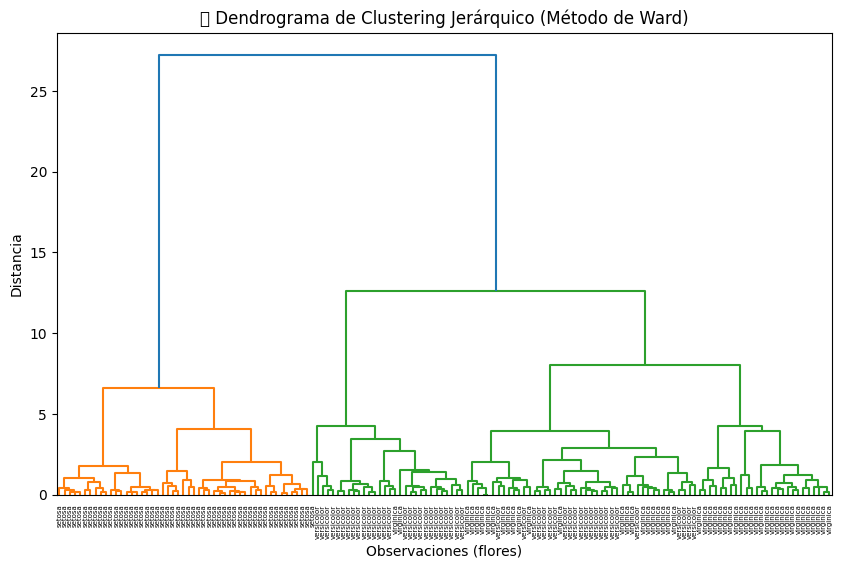

In [ ]:

# Aplicar clustering jerárquico con método Ward
Z = linkage(X_scaled, method='ward')

# Visualizar dendrograma
plt.figure(figsize=(10, 6))
dendrogram(Z, labels=iris['species'].values)
plt.title("🌳 Dendrograma de Clustering Jerárquico (Método de Ward)")
plt.xlabel("Observaciones (flores)")
plt.ylabel("Distancia")
plt.show()



### ✂️ *Selección del número de clusters*

A partir del dendrograma, podemos **“cortar” el árbol** a una cierta altura para definir el número de clusters deseado.  
Usaremos el criterio `maxclust` para obtener 3 grupos, como referencia al número real de especies.


In [ ]:
clusters

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 2,
       3, 3, 3, 3, 3, 3, 3, 2, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 2,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3], dtype=int32)

In [ ]:
# Obtener clusters
clusters = fcluster(Z, t=3, criterion='maxclust')

# Agregar resultado al DataFrame
iris['cluster'] = clusters
iris.head()


,sepal_length,sepal_width,petal_length,petal_width,species,cluster
0,5.1,3.5,1.4,0.2,setosa,1
1,4.9,3.0,1.4,0.2,setosa,1
2,4.7,3.2,1.3,0.2,setosa,1
3,4.6,3.1,1.5,0.2,setosa,1
4,5.0,3.6,1.4,0.2,setosa,1


In [ ]:
iris[['species', 'cluster']].value_counts()

species     cluster
setosa      1          49
virginica   3          48
versicolor  2          27
            3          23
virginica   2           2
setosa      2           1
Name: count, dtype: int64


### 🎨 *Visualización de los clusters obtenidos*

Veamos cómo quedaron distribuidos los clusters en el plano de **longitud y ancho de pétalo**, que suelen ser las variables más discriminantes en este dataset.


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127800 (\N{CHERRY BLOSSOM}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


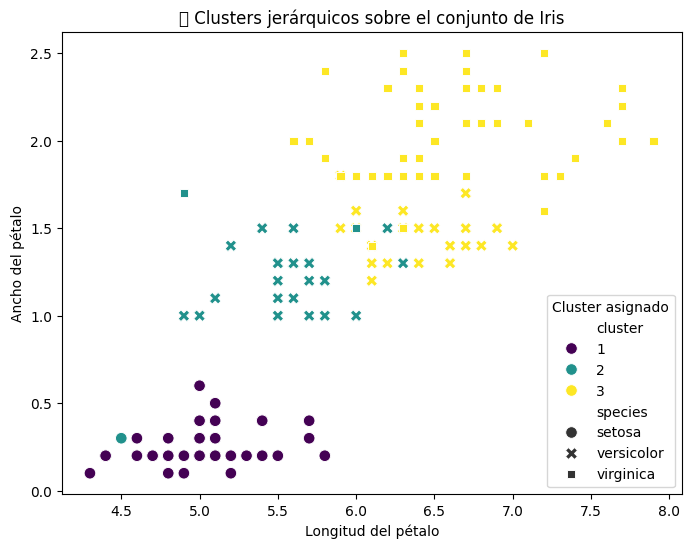

In [ ]:

plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=iris,
    x='sepal_length',
    y='petal_width',
    hue='cluster',
    palette='viridis',
    style='species',
    s=70
)

plt.title("🌸 Clusters jerárquicos sobre el conjunto de Iris")
plt.xlabel("Longitud del pétalo")
plt.ylabel("Ancho del pétalo")
plt.legend(title='Cluster asignado')
plt.show()



### 🧭 *Conclusiones*
- ✅ El **clustering jerárquico** permite descubrir estructuras ocultas en los datos sin conocer previamente el número de grupos.  
- 🌿 En este caso, el modelo logra aproximarse bastante bien a las **tres especies reales** de iris.  
- 🪄 A diferencia de K-means, este enfoque **no requiere inicialización aleatoria** y produce una **visualización jerárquica** que ayuda a interpretar mejor los resultados.  

**✨ En resumen:** es una herramienta muy útil para *análisis exploratorio de datos* cuando la interpretación y la estructura jerárquica son más importantes que la escalabilidad.
